In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
# # # # # # # # # # # # # # # # #

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from seqAE_model import SeqAutoencoder
from training_functions import *

# # # # # # # # # # # #
BS = 16
E = 20
use_losses = ['SupCon', 'Recon']
v = 'debug02'
ds_v = '00'
use_cuda = True
samp = 500
# # # # # # # # # # # #

torch.cuda.empty_cache()

ds, loader = get_ds_and_loader(ds_v, BS, samp=samp)

# print(ds.tokens)
model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

device =  torch.device("cuda" if use_cuda else "cpu")
# if use_cuda and torch.cuda.device_count() > 1:
#     print("Let's use", torch.cuda.device_count(), "GPUs!")
#     model = nn.DataParallel(model)
#     model.to(device)
# else:
model = model.to(device)
    

model.train()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001) 

In [2]:
model = model.eval()

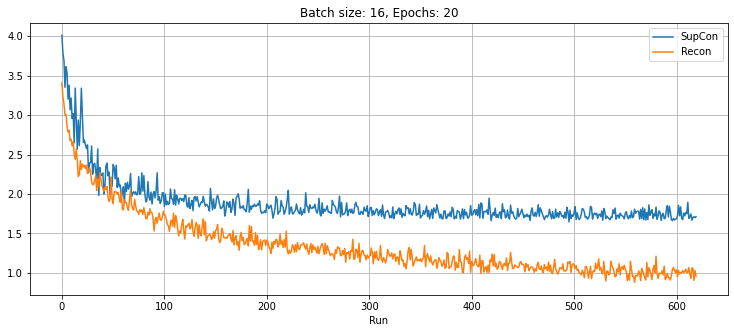

Epoch done. Runtime: 0 mins 25 secs.
All done. Total runtime: 0 hr 8  min 29 sec.


In [3]:
model = fit(model, device, optimizer, loader, use_losses, v, bs=BS, n_epochs=E, 
            normed_latent=True, do_plot=True, save_step=1)

In [4]:
import copy
import random
import numpy as np

# # # # # # # # # # # # # # # # #
samp_size = 50
anc_path = f'data/model_ready/00/train/anchor_smiles.csv'
aug_path = f'data/model_ready/00/train/augmented_smiles.csv'
# # # # # # # # # # # # # # # # #

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)

_df = copy.deepcopy(ds_arr)
_df.reset_index(inplace=True, drop=True)
_df.columns = ['Smiles','Atype','Label'] 

if samp_size < len(anc_map):
    rand = random.sample(range(0,len(anc_map)),samp_size)
    rand_idc = np.concatenate([anc_map[x] for x in rand],axis=0)
    df = _df.iloc[rand_idc]
else:
    df = _df
df.reset_index(inplace=True, drop=True)
display(df)    

,Smiles,Atype,Label
0,O=C(C=Cc1ccc(Br)o1)c1ccc(F)cc1,Anc,9059
1,Nc1cc(C=CC(=O)c2ccc(F)cc2)oc1Br,Aug,9059
2,Cc1cc(F)ccc1C(=O)C=Cc1ccc(Br)o1,Aug,9059
3,CC(=Cc1ccc(Br)o1)C(=O)c1ccc(F)cc1,Aug,9059
4,CC(=CC(=O)c1ccc(F)cc1)c1ccc(Br)o1,Aug,9059
...,...,...,...
295,CC(C)(CBr)Cn1cc2c(Cl)nc(N)nc2n1,Aug,6611
296,CC(C)(CO)Cn1cc2c(Cl)nc(N)nc2n1,Aug,6611
297,Cc1c2c(Cl)nc(N)nc2nn1CC(C)(C)C,Aug,6611
298,CC(C)(C)Cn1cc2c(Cl)nc(NN)nc2n1,Aug,6611


In [ ]:
16*6

In [5]:
import numpy as np
from tqdm.notebook import trange, tqdm

# # # # # # 
test_bs = 1
# # # # # # 

loader = DataLoader(ds, batch_size=test_bs, sampler=range(len(df)), 
                    num_workers=0, pin_memory=True)
latents = []
for samp in tqdm(loader, total=len(df)//test_bs):
    for k,v in samp.items():
        if torch.is_tensor(v):
            samp[k] = v.to(device)
    latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                              samp['avg_mask'], samp['out_mask'])
    latent = latent.cpu().detach().numpy()
    latents.append(latent)
    
latents = np.stack(latents,axis=0)
# if test_bs==1:
latents = latents.squeeze(1)
# latents = np.reshape(latents, (-1,32))
print(latents.shape)

  0%|          | 0/300 [00:00<?, ?it/s]

(300, 32)


In [ ]:
len('#%()+-0123456789<=>BCFHILNOPRSX[]cnos')

In [6]:
# # # # # # # # # # # 
n_neighs = 10
min_dist = 0.05
# # # # # # # # # # # 

import umap.umap_ as umap
umapper = umap.UMAP(n_neighbors=n_neighs, min_dist=min_dist, 
                    n_components=2, metric='euclidean')
embedding = umapper.fit_transform(latents)

df['x'] = embedding[:, 0]
df['y'] = embedding[:, 1]

<AxesSubplot:xlabel='x', ylabel='y'>

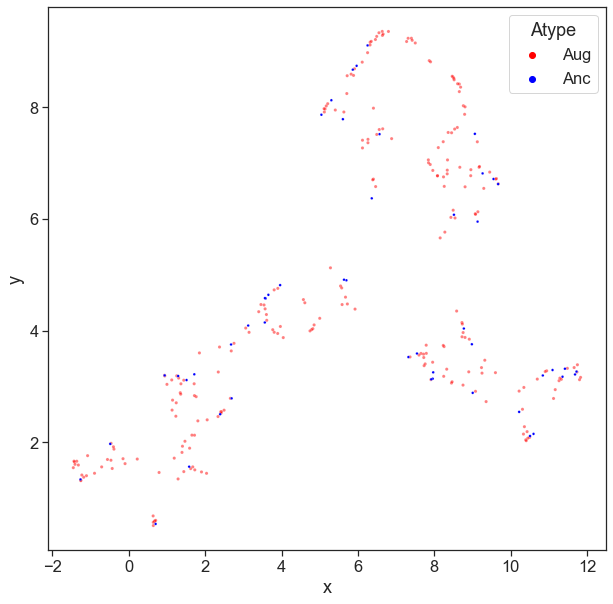

In [7]:
import seaborn as sns 
import matplotlib.pylab as plt

sns.set_theme(style='ticks',font_scale=1.5)

plt.figure(figsize=(10,10))

sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                alpha=0.5, s=10, palette={'Aug':'red'})
sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                alpha=1., s=7, palette={'Anc':'blue'})

In [8]:
from rdkit.Chem import PandasTools
PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)

In [9]:
%matplotlib inline
import plotly.graph_objs as go

from ipywidgets import Image, Layout, HBox, VBox
from rdkit.Chem import Draw
import PIL

import ipywidgets as widgets
import io

# df_anchors = df[df.Atype=='Anc']
# df_augmentations = df[df.Atype=='Aug']

# Assemble all the traces.
trace_anchors = (go.Scattergl(x=df[df.Atype=='Anc']['x'], 
                           y=df[df.Atype=='Anc']['y'], 
                           name='Anchors',
                           marker=dict(size=3, opacity=1., color='blue'),
                           hoverinfo='text',
                           text=df[df.Atype=='Anc']['Smiles'],
                           mode='markers'))
trace_augmentations = (go.Scattergl(x=df[df.Atype=='Aug']['x'], 
                           y=df[df.Atype=='Aug']['y'], 
                           name='Augmentations',
                           marker=dict(size=5, opacity=0.5, color='red'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Atype=='Aug']['Smiles'],
                           mode='markers'))
data = [trace_augmentations, trace_anchors, ]

# Make figure.
fig = go.FigureWidget(data=data)
# fig.layout.hovermode = 'closest'
fig.update_layout(template='simple_white', autosize=False, height=512)
fig.update_yaxes(scaleanchor = "x", scaleratio = 1.)

# Show-mol-on-hover function.
# img = open('white.png','rb').read()
img = PIL.Image.new('1', (256, 256)).tobytes()
image_widget = Image(value=img)

def hover_fn(trace, points, state):
    
    if points.point_inds:
        if trace['name']=='Anchors':
            my_df = df[df.Atype=='Anc']
        elif trace['name']=='Augmentations':
            my_df = df[df.Atype=='Aug']
            
        idx = points.point_inds[0]
        datum = my_df.iloc[idx]
        mol = datum.Mol

        img = Draw.MolToImage(mol,size=(256, 512))  ### to make mol image smaller, alter first dim. 
        imgByteArr = io.BytesIO()
        img.save(imgByteArr, format='PNG')
        imgByteArr = imgByteArr.getvalue()
        image_widget.value = imgByteArr

for trace_num in range(len(fig.data)):
    fig.data[trace_num].on_hover(hover_fn)  
HBox([HBox([image_widget]),fig])